
# Genre Trend Analysis
## How movie genres evolved over time and whether studios produced content aligned with audience demand.

### Analysis Objectives:
- Production volume per genre
- Audience popularity trends
- Market supply vs demand imbalance
- Genre growth and decline
- Profitability and success probability

### Performance Metrics Tracked:
- Data loading time and memory
- Data preparation costs
- Explosion overhead
- GroupBy aggregation performance
- Heatmap generation time
- Normalization and calculation efficiency
- Visualization rendering impact


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import psutil
import os
import ast
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler

print("LOADING LIBRARIES")
print("-"*40)

LOADING LIBRARIES
----------------------------------------


In [3]:
# Start Total Timer and Memory Tracking
print("\nSTARTING ANALYSIS")
print("-"*40)

start_total = time.time()
start_memory_total = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu_total = psutil.Process(os.getpid()).cpu_percent(interval=None)

print(f"Initial memory: {start_memory_total:.2f} MB")


STARTING ANALYSIS
----------------------------------------
Initial memory: 209.78 MB


In [4]:
# Load Data with Benchmarking
print("\nLOADING DATA")
print("-"*40)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

movies = pd.read_csv("movies_cleaned.csv")

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
load_time = execution_time
load_memory = memory_delta
load_end_memory = end_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.2f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"Rows loaded: {len(movies):,}")
print(f"Columns: {len(movies.columns)}")

# Display sample data
print("\nSample data:")
print(movies.head())


LOADING DATA
----------------------------------------

 BENCHMARKS:
Time: 8.61 seconds
Memory delta: 2575.86 MB
Memory total: 2785.77 MB
Rows loaded: 590,202
Columns: 166

Sample data:
   id                title  vote_average  vote_count    status release_date  \
0   2                Ariel           7.1         367  Released   1988-10-21   
1   3  Shadows in Paradise           7.3         430  Released   1986-10-17   
2   5           Four Rooms           5.9        2780  Released   1995-12-09   
3   6       Judgment Night           6.5         360  Released   1993-10-15   
4   9     Sunday in August           6.8          28  Released   2004-09-02   

    revenue  runtime    budget    imdb_id  ... director_count  \
0         0       73         0  tt0094675  ...              1   
1         0       74         0  tt0092149  ...              1   
2   4257354       98   4000000  tt0113101  ...              4   
3  12136938      109  21000000  tt0107286  ...              1   
4         0   

In [5]:
print("\n" + "="*80)
print("DATA PREPARATION: DATE + DECADE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Convert release_date to datetime
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')

# Extract year
movies['year'] = movies['release_date'].dt.year

# Create decade column (1995 → 1990s)
movies['decade'] = (movies['year'] // 10) * 10

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n RESULTS:")
print(movies[['release_date', 'year', 'decade']].head())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

# Store metrics
prep_date_time = execution_time
prep_date_memory = memory_delta


DATA PREPARATION: DATE + DECADE

 RESULTS:
  release_date  year  decade
0   1988-10-21  1988    1980
1   1986-10-17  1986    1980
2   1995-12-09  1995    1990
3   1993-10-15  1993    1990
4   2004-09-02  2004    2000

 BENCHMARKS:
Time: 0.0888 seconds
Memory delta: -247.28 MB
Memory total: 2538.94 MB


In [6]:
print("\n" + "="*80)
print("DATA PREPARATION: CLEAN AND SPLIT GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Split into list
movies['genres_list'] = movies['genres'].str.split(',')

# Strip spaces and remove duplicates
def clean_genres(x):
    if isinstance(x, list):
        cleaned = [g.strip() for g in x]
        return list(set(cleaned))
    return []

movies['genres_list'] = movies['genres_list'].apply(clean_genres)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Calculate statistics
genres_per_movie = movies['genres_list'].apply(len)
avg_genres = genres_per_movie.mean()
max_genres = genres_per_movie.max()
movies_with_genres = (genres_per_movie > 0).sum()

print(f"\n RESULTS:")
print(f"Movies with at least one genre: {movies_with_genres:,} ({movies_with_genres/len(movies)*100:.1f}%)")
print(f"Average genres per movie: {avg_genres:.2f}")
print(f"Maximum genres in a movie: {max_genres}")
print("\nSample data:")
print(movies[['genres', 'genres_list']].head(10))

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"Processing speed: {len(movies)/execution_time:,.0f} rows/second")

# Store metrics
prep_genres_time = execution_time
prep_genres_memory = memory_delta


DATA PREPARATION: CLEAN AND SPLIT GENRES

 RESULTS:
Movies with at least one genre: 590,202 (100.0%)
Average genres per movie: 1.65
Maximum genres in a movie: 12

Sample data:
                               genres                           genres_list
0       Comedy, Drama, Romance, Crime       [Comedy, Drama, Romance, Crime]
1              Comedy, Drama, Romance              [Comedy, Drama, Romance]
2                              Comedy                              [Comedy]
3             Action, Crime, Thriller             [Action, Crime, Thriller]
4                               Drama                               [Drama]
5  Adventure, Action, Science Fiction  [Action, Adventure, Science Fiction]
6                   Animation, Family                   [Animation, Family]
7              Comedy, Drama, Romance              [Comedy, Drama, Romance]
8                               Drama                               [Drama]
9                      Mystery, Drama                      [Dra

In [7]:
print("\n" + "="*80)
print("DATA PREPARATION: EXPLODE GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Explode genres
movies_genre = movies.explode('genres_list')
movies_genre = movies_genre.rename(columns={'genres_list': 'genre'})

# Drop rows with null genres
movies_genre = movies_genre[movies_genre['genre'].notna()]

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_before = len(movies)
rows_after = len(movies_genre)
expansion_factor = rows_after / rows_before

print(f"\n RESULTS:")
print(f"Rows before explosion: {rows_before:,}")
print(f"Rows after explosion: {rows_after:,}")
print(f"Expansion factor: {expansion_factor:.2f}x")
print(f"New rows created: {rows_after - rows_before:,}")
print("\nSample data:")
print(movies_genre.head(10))

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"Explosion speed: {rows_after/execution_time:,.0f} rows/second")

# Store metrics
explode_time = execution_time
explode_memory = memory_delta
rows_exploded = rows_after


DATA PREPARATION: EXPLODE GENRES

 RESULTS:
Rows before explosion: 590,202
Rows after explosion: 976,352
Expansion factor: 1.65x
New rows created: 386,150

Sample data:
   id                title  vote_average  vote_count    status release_date  \
0   2                Ariel           7.1         367  Released   1988-10-21   
0   2                Ariel           7.1         367  Released   1988-10-21   
0   2                Ariel           7.1         367  Released   1988-10-21   
0   2                Ariel           7.1         367  Released   1988-10-21   
1   3  Shadows in Paradise           7.3         430  Released   1986-10-17   
1   3  Shadows in Paradise           7.3         430  Released   1986-10-17   
1   3  Shadows in Paradise           7.3         430  Released   1986-10-17   
2   5           Four Rooms           5.9        2780  Released   1995-12-09   
3   6       Judgment Night           6.5         360  Released   1993-10-15   
3   6       Judgment Night           6.5

In [8]:
print("\n" + "="*80)
print("ANALYSIS 1: GENRE FREQUENCY BY DECADE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Group by decade and genre
genre_counts = (
    movies_genre
    .groupby(['decade', 'genre'])
    .size()
    .reset_index(name='movie_count')
)

# Pivot for visualization
genre_counts_pivot = genre_counts.pivot(index='decade', columns='genre', values='movie_count').fillna(0)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(genre_counts)
rows_per_sec = rows_processed / execution_time if execution_time > 0 else 0

# Store metrics for summary
analysis1_time = execution_time
analysis1_memory = memory_delta

print(f"\n RESULTS:")
print(f"Total decade-genre combinations: {rows_processed:,}")
print(f"Unique decades: {genre_counts['decade'].nunique()}")
print(f"Unique genres: {genre_counts['genre'].nunique()}")
print(f"Total movies counted: {genre_counts['movie_count'].sum():,}")
print("\nSample data:")
print(genre_counts.head())
print("\nPivot table sample (last 5 rows):")
print(genre_counts_pivot.tail())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Groups created: {rows_processed:,}")
print(f"Groups/second: {rows_per_sec:,.0f}")


ANALYSIS 1: GENRE FREQUENCY BY DECADE

 RESULTS:
Total decade-genre combinations: 268
Unique decades: 17
Unique genres: 19
Total movies counted: 976,352

Sample data:
   decade        genre  movie_count
0    1880  Documentary            2
1    1890       Action            6
2    1890    Animation            3
3    1890       Comedy           49
4    1890        Crime            2

Pivot table sample (last 5 rows):
genre    Action  Adventure  Animation   Comedy   Crime  Documentary    Drama  \
decade                                                                         
2000     6310.0     2684.0     3572.0  17688.0  4342.0      14417.0  27734.0   
2010    10031.0     4942.0     6298.0  33593.0  7207.0      29243.0  59018.0   
2020     9063.0     4787.0     6687.0  36025.0  8152.0      31282.0  66704.0   
2030        0.0        1.0        0.0      0.0     0.0          1.0      0.0   
2060        0.0        1.0        0.0      0.0     1.0          0.0      0.0   

genre   Family  Fant


VISUALIZATION: PRODUCTION TRENDS HEATMAP


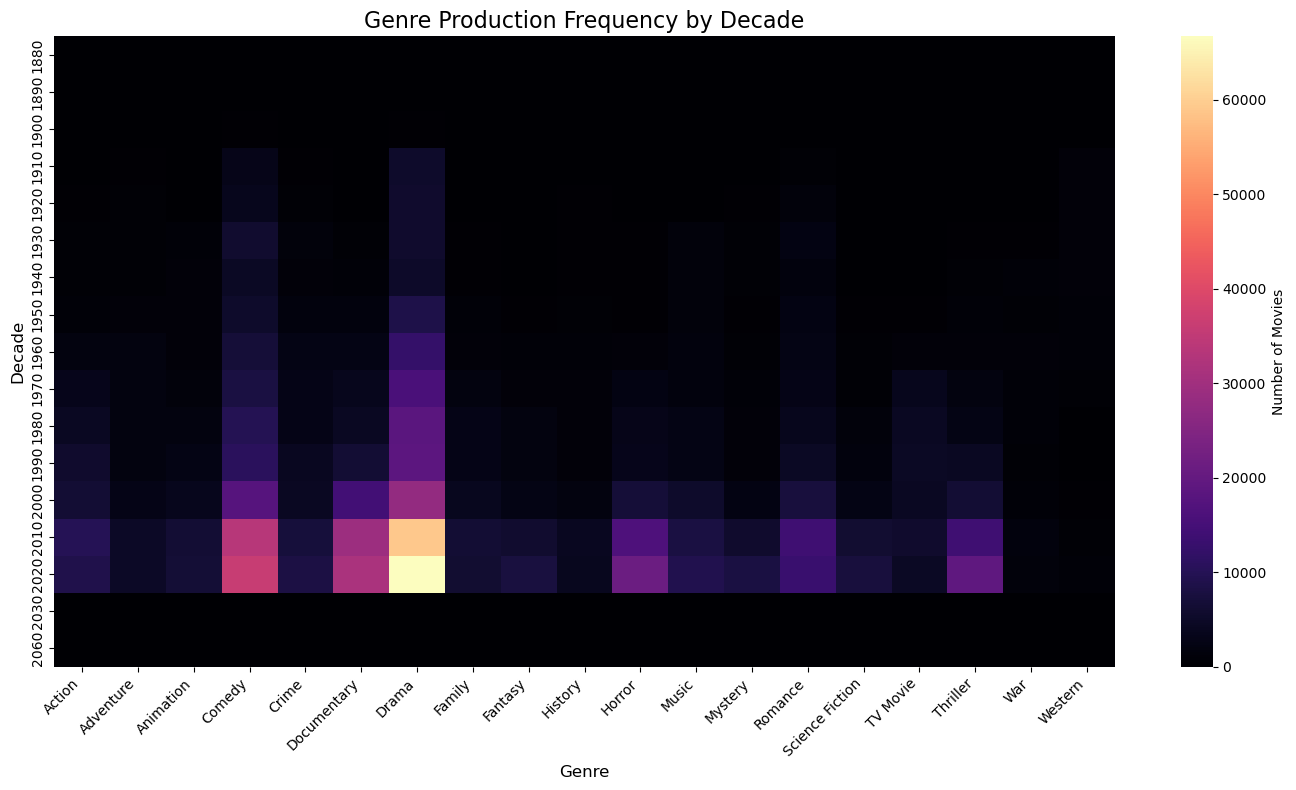


 BENCHMARKS:
Time: 0.1808 seconds
Memory delta: 26.95 MB
Memory total: 2832.28 MB


In [9]:
print("\n" + "="*80)
print("VISUALIZATION: PRODUCTION TRENDS HEATMAP")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(genre_counts_pivot, cmap='magma', cbar_kws={'label': 'Number of Movies'})
plt.title("Genre Production Frequency by Decade", fontsize=16)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Decade", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

viz1_time = execution_time
viz1_memory = memory_delta

In [10]:
print("\n" + "="*80)
print("ANALYSIS 2: AUDIENCE INTEREST - POPULARITY BY DECADE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Calculate average popularity per genre-decade
genre_popularity = (
    movies_genre
    .groupby(['decade', 'genre'])['popularity']
    .mean()
    .reset_index(name='avg_popularity')
)

# Pivot for visualization
popularity_pivot = genre_popularity.pivot(index='decade', columns='genre', values='avg_popularity')

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory
rows_processed = len(genre_popularity)
rows_per_sec = rows_processed / execution_time if execution_time > 0 else 0

# Store metrics for summary
analysis2_time = execution_time
analysis2_memory = memory_delta

print(f"\n RESULTS:")
print(f"Total decade-genre popularity records: {rows_processed:,}")
print(f"Average popularity range: {genre_popularity['avg_popularity'].min():.2f} - {genre_popularity['avg_popularity'].max():.2f}")
print("\nSample data:")
print(genre_popularity.head())
print("\nPopularity pivot sample:")
print(popularity_pivot.head())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Groups processed: {rows_processed:,}")
print(f"Groups/second: {rows_per_sec:,.0f}")


ANALYSIS 2: AUDIENCE INTEREST - POPULARITY BY DECADE

 RESULTS:
Total decade-genre popularity records: 268
Average popularity range: 0.03 - 5.81

Sample data:
   decade        genre  avg_popularity
0    1880  Documentary        0.747600
1    1890       Action        1.921817
2    1890    Animation        0.889633
3    1890       Comedy        0.918353
4    1890        Crime        1.742500

Popularity pivot sample:
genre     Action  Adventure  Animation    Comedy     Crime  Documentary  \
decade                                                                    
1880         NaN        NaN        NaN       NaN       NaN     0.747600   
1890    1.921817        NaN   0.889633  0.918353  1.742500     0.979580   
1900    0.495074   0.749169   0.290883  0.406860  0.456824     0.459855   
1910    0.971315   0.780037   0.992938  0.696313  0.706553     0.520740   
1920    0.986048   0.918032   0.840525  0.907575  0.917242     0.706002   

genre      Drama    Family   Fantasy   History    Horr


VISUALIZATION: AUDIENCE INTEREST HEATMAP


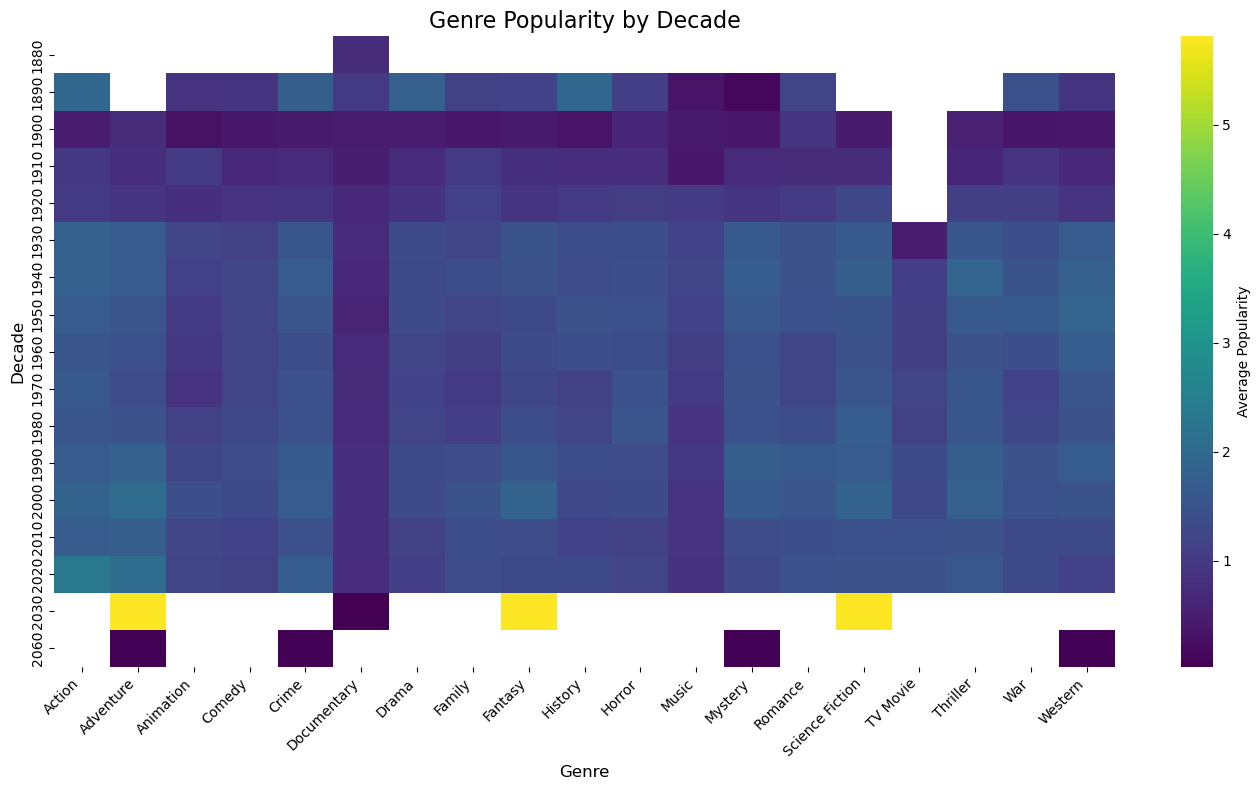


 BENCHMARKS:
Time: 0.1381 seconds
Memory delta: 1.08 MB
Memory total: 2852.05 MB


In [11]:
print("\n" + "="*80)
print("VISUALIZATION: AUDIENCE INTEREST HEATMAP")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Create heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(popularity_pivot, cmap='viridis', cbar_kws={'label': 'Average Popularity'})
plt.title("Genre Popularity by Decade", fontsize=16)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Decade", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

viz2_time = execution_time
viz2_memory = memory_delta

In [12]:
print("\n" + "="*80)
print("ANALYSIS 3: COMBINE VOLUME AND INTEREST")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Merge datasets
genre_trends = pd.merge(genre_counts, genre_popularity, on=['decade', 'genre'])

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n RESULTS:")
print(f"Combined dataset shape: {genre_trends.shape}")
print("\nSample data:")
print(genre_trends.head())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

merge_time = execution_time
merge_memory = memory_delta


ANALYSIS 3: COMBINE VOLUME AND INTEREST

 RESULTS:
Combined dataset shape: (268, 4)

Sample data:
   decade        genre  movie_count  avg_popularity
0    1880  Documentary            2        0.747600
1    1890       Action            6        1.921817
2    1890    Animation            3        0.889633
3    1890       Comedy           49        0.918353
4    1890        Crime            2        1.742500

 BENCHMARKS:
Time: 0.0010 seconds
Memory delta: 0.38 MB
Memory total: 2852.44 MB


In [13]:
print("\n" + "="*80)
print("ANALYSIS 4: DEMAND-SUPPLY GAP ANALYSIS")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Normalize both metrics
scaler = MinMaxScaler()
genre_trends[['count_norm', 'pop_norm']] = scaler.fit_transform(
    genre_trends[['movie_count', 'avg_popularity']]
)

# Calculate demand gap (positive = underproduced, negative = oversaturated)
genre_trends['demand_gap'] = genre_trends['pop_norm'] - genre_trends['count_norm']

# Get latest decade
latest_decade = genre_trends['decade'].max()
gap_latest = genre_trends[genre_trends['decade'] == latest_decade].copy()

# Sort for visualization
gap_latest_under = gap_latest.sort_values('demand_gap', ascending=False).head(15)
gap_latest_over = gap_latest.sort_values('demand_gap', ascending=True).head(15)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
analysis4_time = execution_time
analysis4_memory = memory_delta

print(f"\n RESULTS:")
print(f"Latest decade analyzed: {latest_decade}s")
print(f"\nTop 5 UNDERPRODUCED genres (high demand, low supply):")
print(gap_latest_under[['genre', 'demand_gap', 'movie_count', 'avg_popularity']].head())
print(f"\nTop 5 OVERSATURATED genres (low demand, high supply):")
print(gap_latest_over[['genre', 'demand_gap', 'movie_count', 'avg_popularity']].head())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Records processed: {len(genre_trends):,}")


ANALYSIS 4: DEMAND-SUPPLY GAP ANALYSIS

 RESULTS:
Latest decade analyzed: 2060s

Top 5 UNDERPRODUCED genres (high demand, low supply):
         genre  demand_gap  movie_count  avg_popularity
264  Adventure    0.007402            1          0.0714
265      Crime    0.007402            1          0.0714
266    Mystery    0.007402            1          0.0714
267    Western    0.007402            1          0.0714

Top 5 OVERSATURATED genres (low demand, high supply):
         genre  demand_gap  movie_count  avg_popularity
264  Adventure    0.007402            1          0.0714
265      Crime    0.007402            1          0.0714
266    Mystery    0.007402            1          0.0714
267    Western    0.007402            1          0.0714

 BENCHMARKS:
Time: 0.0043 seconds
Memory delta: 1.50 MB
Memory total: 2854.23 MB
CPU: 0.0%
Records processed: 268



VISUALIZATION: MOST UNDERPRODUCED GENRES


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/200443458.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_latest_under.tail(10), x='demand_gap', y='genre', palette='viridis')


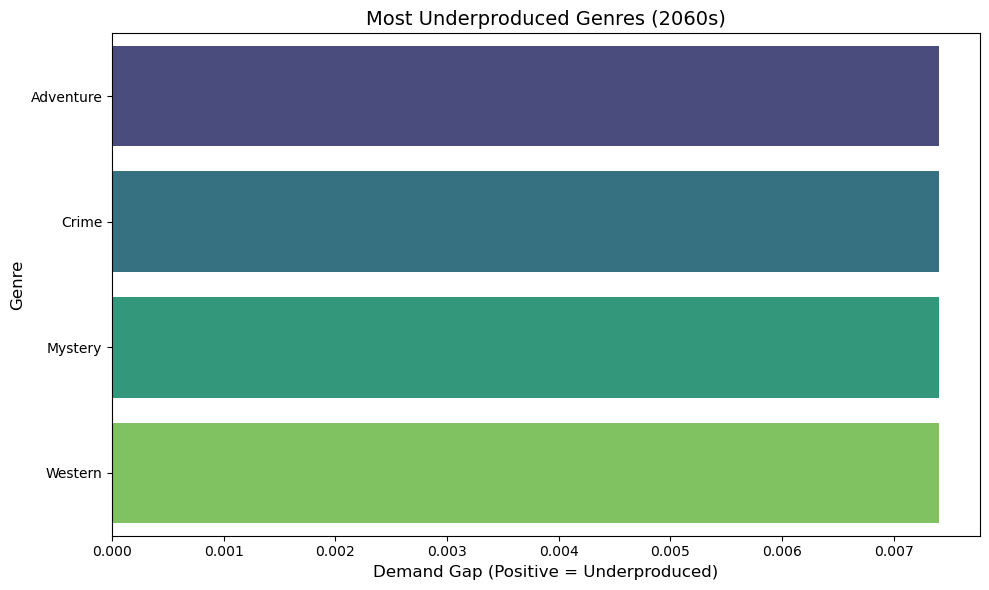


 BENCHMARKS:
Time: 0.0714 seconds
Memory delta: 4.89 MB


In [14]:
print("\n" + "="*80)
print("VISUALIZATION: MOST UNDERPRODUCED GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.barplot(data=gap_latest_under.tail(10), x='demand_gap', y='genre', palette='viridis')
plt.title(f"Most Underproduced Genres ({latest_decade}s)", fontsize=14)
plt.xlabel("Demand Gap (Positive = Underproduced)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")

viz3_time = execution_time
viz3_memory = memory_delta


VISUALIZATION: MOST OVERSATURATED GENRES


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/293242078.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gap_latest_over.head(10), x='demand_gap', y='genre', palette='magma')


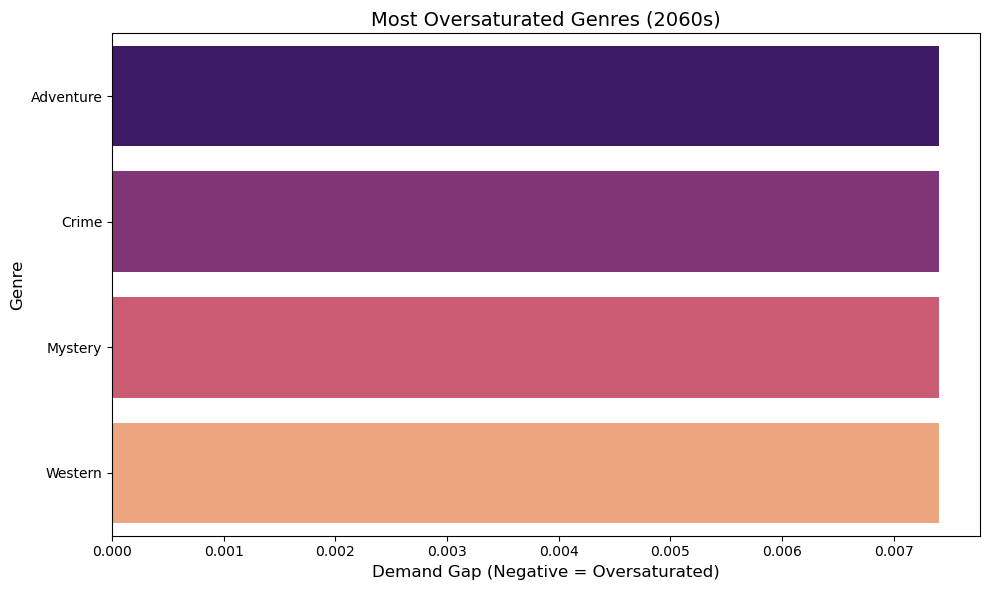


 BENCHMARKS:
Time: 0.0712 seconds
Memory delta: 1.44 MB


In [15]:
print("\n" + "="*80)
print("VISUALIZATION: MOST OVERSATURATED GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.barplot(data=gap_latest_over.head(10), x='demand_gap', y='genre', palette='magma')
plt.title(f"Most Oversaturated Genres ({latest_decade}s)", fontsize=14)
plt.xlabel("Demand Gap (Negative = Oversaturated)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")

viz4_time = execution_time
viz4_memory = memory_delta

In [16]:
print("\n" + "="*80)
print("ANALYSIS 5: RISING VS DECLINING GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Sort for time series analysis
genre_popularity_sorted = genre_popularity.sort_values(['genre', 'decade'])

# Calculate popularity change between decades
genre_popularity_sorted['pop_change'] = (
    genre_popularity_sorted
    .groupby('genre')['avg_popularity']
    .diff()
)

# Calculate average trend score
trend_score = (
    genre_popularity_sorted.groupby('genre')['pop_change']
    .mean()
    .reset_index(name='avg_trend')
    .sort_values('avg_trend', ascending=False)
)

rising_genres = trend_score.head(10)
declining_genres = trend_score.tail(10)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
analysis5_time = execution_time
analysis5_memory = memory_delta

print(f"\n RESULTS:")
print("\nTop 5 Rising Genres (increasing popularity):")
print(rising_genres.head())
print("\nTop 5 Declining Genres (decreasing popularity):")
print(declining_genres.head())
print("\nSample of popularity changes:")
print(genre_popularity_sorted.head(20))

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Genres analyzed: {len(trend_score)}")


ANALYSIS 5: RISING VS DECLINING GENRES

 RESULTS:

Top 5 Rising Genres (increasing popularity):
              genre  avg_trend
14  Science Fiction   0.411905
8           Fantasy   0.331680
15         TV Movie   0.113026
16         Thriller   0.086520
11            Music   0.040225

Top 5 Declining Genres (decreasing popularity):
      genre  avg_trend
7    Family   0.014756
10   Horror   0.007618
12  Mystery  -0.005296
17      War  -0.010346
9   History  -0.047568

Sample of popularity changes:
     decade      genre  avg_popularity  pop_change
1      1890     Action        1.921817         NaN
16     1900     Action        0.495074   -1.426743
34     1910     Action        0.971315    0.476241
52     1920     Action        0.986048    0.014732
70     1930     Action        1.793765    0.807717
89     1940     Action        1.806933    0.013168
108    1950     Action        1.666360   -0.140573
127    1960     Action        1.563832   -0.102528
146    1970     Action        1.621335  


VISUALIZATION: FASTEST GROWING GENRES


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/816926344.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rising_genres.head(10), x='avg_trend', y='genre', palette='Greens')


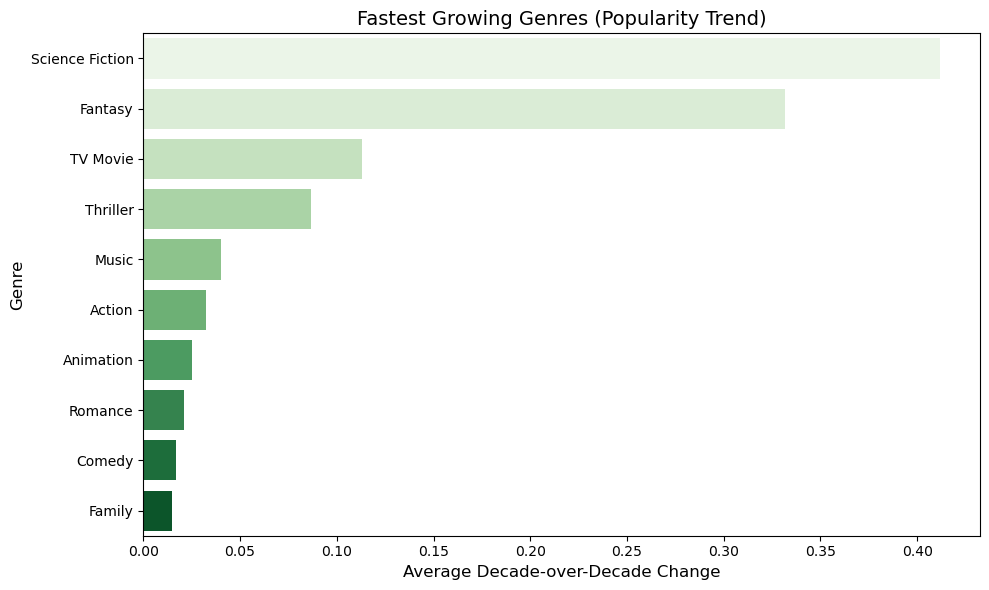


 BENCHMARKS:
Time: 0.0938 seconds
Memory delta: 0.89 MB


In [17]:
print("\n" + "="*80)
print("VISUALIZATION: FASTEST GROWING GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.barplot(data=rising_genres.head(10), x='avg_trend', y='genre', palette='Greens')
plt.title("Fastest Growing Genres (Popularity Trend)", fontsize=14)
plt.xlabel("Average Decade-over-Decade Change", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")

viz5_time = execution_time
viz5_memory = memory_delta


VISUALIZATION: FASTEST DECLINING GENRES


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/1178403674.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=declining_genres.head(10), x='avg_trend', y='genre', palette='Reds')


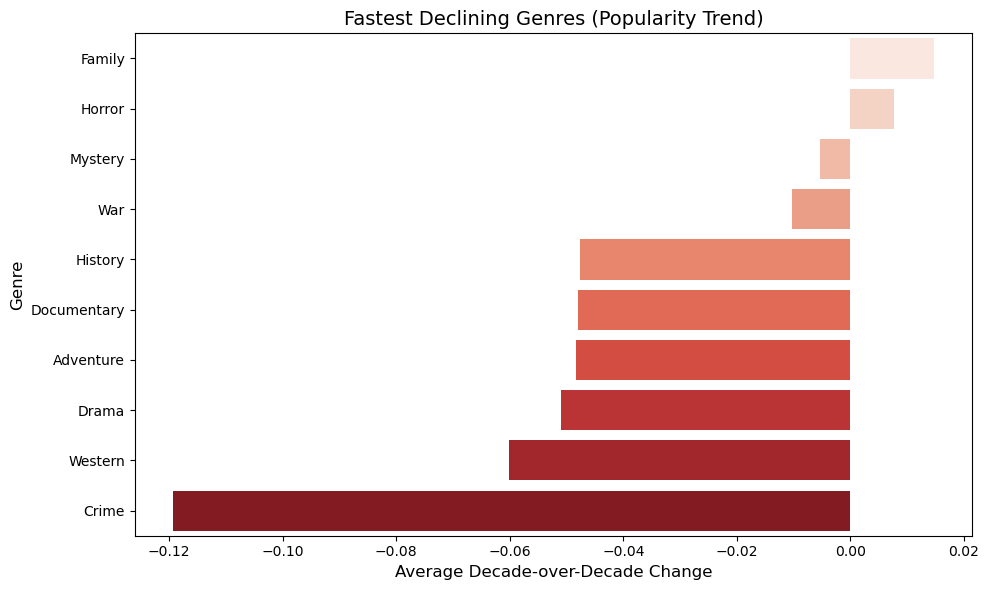


 BENCHMARKS:
Time: 0.0993 seconds
Memory delta: 0.34 MB


In [18]:
print("\n" + "="*80)
print("VISUALIZATION: FASTEST DECLINING GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.barplot(data=declining_genres.head(10), x='avg_trend', y='genre', palette='Reds')
plt.title("Fastest Declining Genres (Popularity Trend)", fontsize=14)
plt.xlabel("Average Decade-over-Decade Change", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")

viz6_time = execution_time
viz6_memory = memory_delta

In [19]:
print("\n" + "="*80)
print("ANALYSIS 6: GENRE STABILITY (VOLATILITY)")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Calculate volatility as standard deviation of popularity
genre_variability = (
    genre_popularity.groupby('genre')['avg_popularity']
    .std()
    .reset_index(name='popularity_volatility')
    .sort_values('popularity_volatility', ascending=False)
)

most_volatile = genre_variability.head(10)
most_stable = genre_variability.tail(10)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
analysis6_time = execution_time
analysis6_memory = memory_delta

print(f"\n RESULTS:")
print("\nTop 5 Most Volatile Genres (fads, unpredictable):")
print(most_volatile.head())
print("\nTop 5 Most Stable Genres (consistent popularity):")
print(most_stable.tail())

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")
print(f"Genres analyzed: {len(genre_variability)}")


ANALYSIS 6: GENRE STABILITY (VOLATILITY)

 RESULTS:

Top 5 Most Volatile Genres (fads, unpredictable):
              genre  popularity_volatility
1         Adventure               1.264769
14  Science Fiction               1.234025
8           Fantasy               1.220124
12          Mystery               0.577299
18          Western               0.545738

Top 5 Most Stable Genres (consistent popularity):
          genre  popularity_volatility
2     Animation               0.269178
10       Horror               0.263621
3        Comedy               0.263180
13      Romance               0.257815
5   Documentary               0.210351

 BENCHMARKS:
Time: 0.0012 seconds
Memory delta: 0.05 MB
Memory total: 2862.80 MB
CPU: 0.0%
Genres analyzed: 19


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/586294329.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=most_volatile.head(10), x='popularity_volatility', y='genre', palette='coolwarm')



VISUALIZATION: MOST VOLATILE GENRES


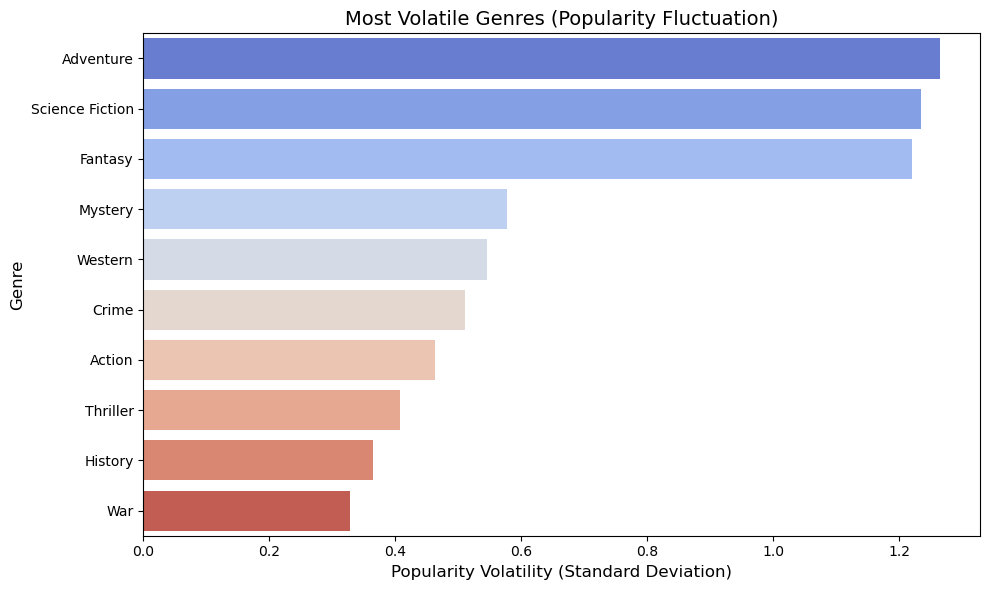


 BENCHMARKS:
Time: 0.0900 seconds
Memory delta: 0.69 MB


In [20]:
print("\n" + "="*80)
print("VISUALIZATION: MOST VOLATILE GENRES")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

plt.figure(figsize=(10, 6))
sns.barplot(data=most_volatile.head(10), x='popularity_volatility', y='genre', palette='coolwarm')
plt.title("Most Volatile Genres (Popularity Fluctuation)", fontsize=14)
plt.xlabel("Popularity Volatility (Standard Deviation)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")

viz7_time = execution_time
viz7_memory = memory_delta

In [21]:
print("\n" + "="*80)
print("ANALYSIS 7: GENRE PROFITABILITY (ROI)")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Calculate ROI
movies['roi'] = (movies['revenue'] - movies['budget']) / movies['budget']
movies['roi'] = movies['roi'].replace([np.inf, -np.inf], np.nan)

# Use already exploded dataframe
movies_genre_roi = movies.explode('genres_list').rename(columns={'genres_list': 'genre'})
movies_genre_roi = movies_genre_roi[movies_genre_roi['genre'].notna()]

# Calculate median ROI by genre
genre_roi = (
    movies_genre_roi.groupby('genre')['roi']
    .median()
    .reset_index(name='median_roi')
    .sort_values('median_roi', ascending=False)
)

# Calculate mean ROI and count for context
genre_roi_stats = (
    movies_genre_roi.groupby('genre')['roi']
    .agg(['median', 'mean', 'count'])
    .reset_index()
    .sort_values('median', ascending=False)
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
analysis7_time = execution_time
analysis7_memory = memory_delta

print(f"\n RESULTS:")
print("Top 10 Genres by Median ROI:")
print(genre_roi_stats.head(10))
print("\nMovies with ROI calculated: {:,}".format(movies_genre_roi['roi'].notna().sum()))
print(f"Average ROI across all genres: {genre_roi_stats['mean'].mean():.2f}")

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")


ANALYSIS 7: GENRE PROFITABILITY (ROI)

 RESULTS:
Top 10 Genres by Median ROI:
              genre    median          mean  count
1         Adventure -0.917083     53.990470   4011
0            Action -1.000000  17890.376167   6528
10           Horror -1.000000    507.520078  10829
17              War -1.000000      0.754526   1160
16         Thriller -1.000000   2465.847629  10380
15         TV Movie -1.000000   9340.338779    571
14  Science Fiction -1.000000   5806.956190   4364
13          Romance -1.000000   1467.063161   5941
12          Mystery -1.000000   6535.590329   3897
11            Music -1.000000   1291.120824   1959

Movies with ROI calculated: 111,596
Average ROI across all genres: 3404.55

 BENCHMARKS:
Time: 2.6050 seconds
Memory delta: 45.84 MB
Memory total: 2909.53 MB
CPU: 0.0%



VISUALIZATION: ROI DISTRIBUTION BY GENRE
Top genres selected: ['Adventure', 'Action', 'Horror', 'War', 'Thriller', 'TV Movie', 'Science Fiction', 'Romance']
Data points for visualization: 43,784
ROI range after clipping: -1.00 to 29.94


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/1159398324.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=plot_data, x='genre', y='roi_clipped', palette='Set2')


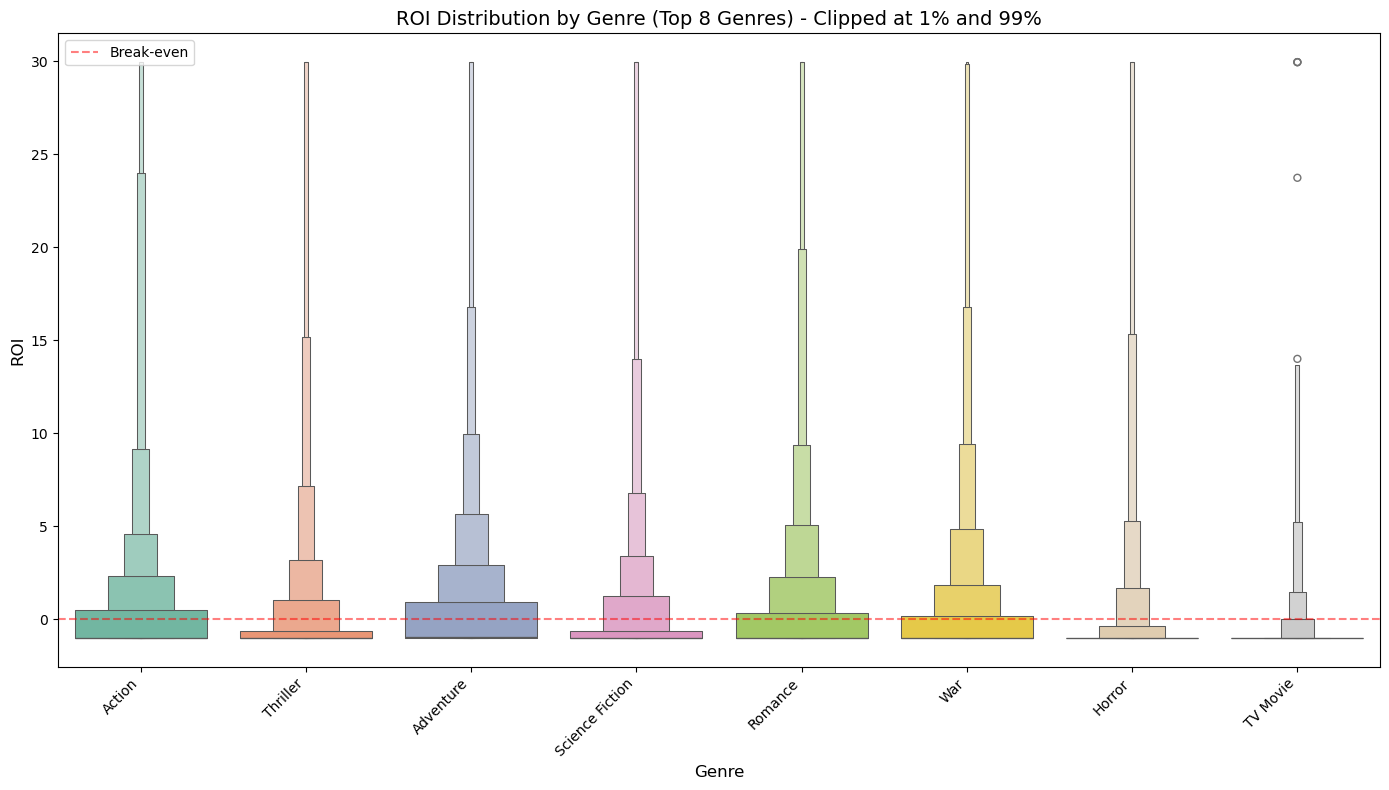


 BENCHMARKS:
Time: 0.4403 seconds
Memory delta: 233.95 MB
Memory total: 3144.72 MB


In [22]:
print("\n" + "="*80)
print("VISUALIZATION: ROI DISTRIBUTION BY GENRE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Get top genres for visualization
top_genres = genre_roi_stats.head(8)['genre'].tolist()
print(f"Top genres selected: {top_genres}")

# Filter data for top genres and remove any potential duplicates
plot_data = movies_genre_roi[movies_genre_roi['genre'].isin(top_genres)].copy()

# Remove any rows with NaN ROI
plot_data = plot_data[plot_data['roi'].notna()]

# Clip extreme values for better visualization
q1 = plot_data['roi'].quantile(0.01)
q99 = plot_data['roi'].quantile(0.99)
plot_data['roi_clipped'] = plot_data['roi'].clip(q1, q99)

print(f"Data points for visualization: {len(plot_data):,}")
print(f"ROI range after clipping: {q1:.2f} to {q99:.2f}")

# Create visualization
plt.figure(figsize=(14, 8))

# Use boxen plot for better visualization of large datasets
sns.boxenplot(data=plot_data, x='genre', y='roi_clipped', palette='Set2')

plt.xticks(rotation=45, ha='right')
plt.title(f"ROI Distribution by Genre (Top 8 Genres) - Clipped at 1% and 99%", fontsize=14)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("ROI", fontsize=12)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
plt.legend()
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

viz8_time = execution_time
viz8_memory = memory_delta

In [23]:
print("\n" + "="*80)
print("ANALYSIS 8: SUCCESS PROBABILITY BY GENRE")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
start_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

# Define hit threshold (75th percentile of popularity)
hit_threshold = movies['popularity'].quantile(0.75)
movies['is_hit'] = movies['popularity'] >= hit_threshold

# Use exploded dataframe
movies_genre_hit = movies.explode('genres_list').rename(columns={'genres_list': 'genre'})
movies_genre_hit = movies_genre_hit[movies_genre_hit['genre'].notna()]

# Calculate hit probability by genre
genre_hit_rate = (
    movies_genre_hit.groupby('genre')['is_hit']
    .mean()
    .reset_index(name='hit_probability')
    .sort_values('hit_probability', ascending=False)
)

# Add count for context
genre_hit_stats = (
    movies_genre_hit.groupby('genre')
    .agg(
        hit_probability=('is_hit', 'mean'),
        total_movies=('id', 'count')
    )
    .reset_index()
    .sort_values('hit_probability', ascending=False)
)

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu = psutil.Process(os.getpid()).cpu_percent(interval=None)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

# Store metrics for summary
analysis8_time = execution_time
analysis8_memory = memory_delta

print(f"\n RESULTS:")
print(f"Hit threshold (75th percentile popularity): {hit_threshold:.2f}")
print("\nTop 10 Genres by Hit Probability:")
print(genre_hit_stats.head(10))
print(f"\nOverall hit rate across all movies: {movies['is_hit'].mean()*100:.1f}%")

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")
print(f"CPU: {end_cpu:.1f}%")


ANALYSIS 8: SUCCESS PROBABILITY BY GENRE

 RESULTS:
Hit threshold (75th percentile popularity): 1.40

Top 10 Genres by Hit Probability:
              genre  hit_probability  total_movies
0            Action         0.412046         43318
1         Adventure         0.375132         23733
4             Crime         0.365809         37115
16         Thriller         0.364547         51900
18          Western         0.358836          9241
13          Romance         0.353388         56213
15         TV Movie         0.336649         28246
17              War         0.335974         10349
12          Mystery         0.331142         22208
14  Science Fiction         0.327264         21145

Overall hit rate across all movies: 26.1%

 BENCHMARKS:
Time: 2.8848 seconds
Memory delta: 83.80 MB
Memory total: 3228.73 MB
CPU: 0.0%



VISUALIZATION: GENRES MOST LIKELY TO PRODUCE HITS


/var/folders/bn/dd9jjh3s7rdbkwp57bcgflw00000gn/T/ipykernel_14470/3347087313.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hit_genres, x='hit_probability', y='genre', palette='viridis')


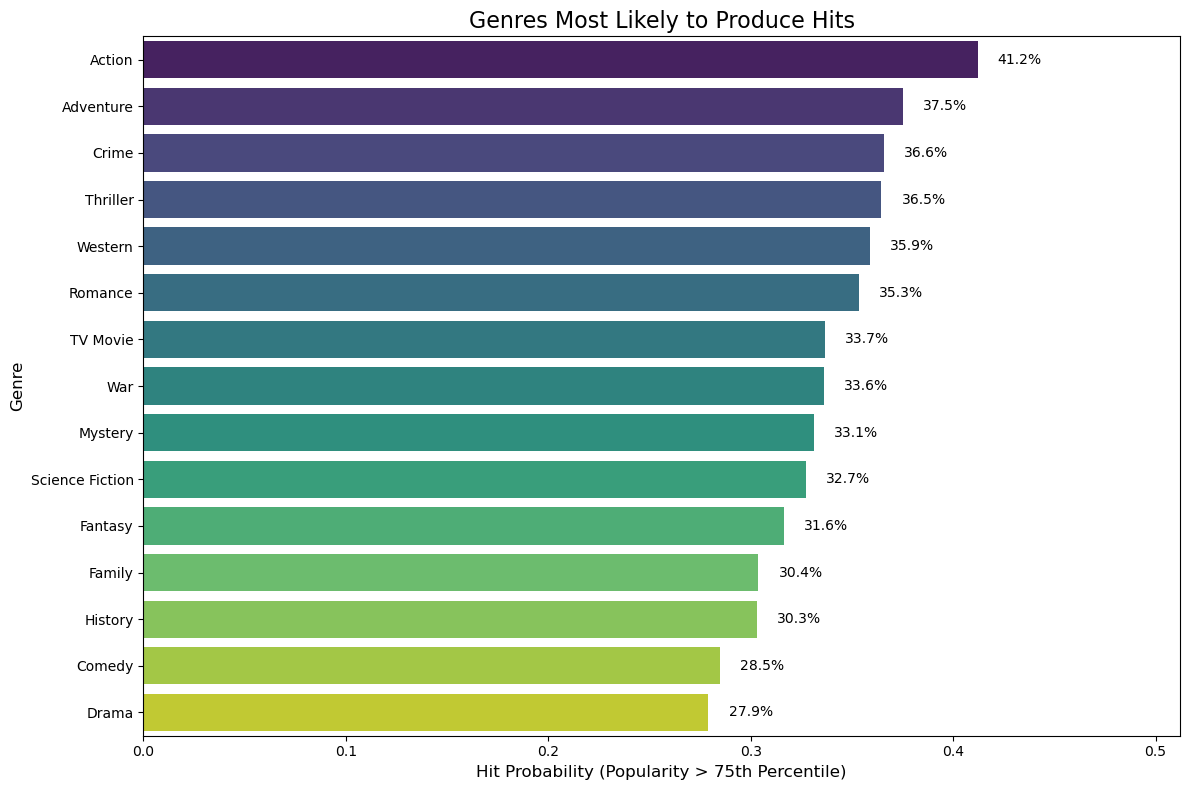


 BENCHMARKS:
Time: 0.1245 seconds
Memory delta: 12.20 MB
Memory total: 3242.16 MB


In [24]:
print("\n" + "="*80)
print("VISUALIZATION: GENRES MOST LIKELY TO PRODUCE HITS")
print("="*80)

start_time = time.time()
start_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

# Get top 15 genres for visualization
top_hit_genres = genre_hit_stats.head(15).copy()

# Create visualization
plt.figure(figsize=(12, 8))

# Use horizontal bar plot for better readability
sns.barplot(data=top_hit_genres, x='hit_probability', y='genre', palette='viridis')

plt.title("Genres Most Likely to Produce Hits", fontsize=16)
plt.xlabel("Hit Probability (Popularity > 75th Percentile)", fontsize=12)
plt.ylabel("Genre", fontsize=12)

# Add value labels
for i, v in enumerate(top_hit_genres['hit_probability']):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center')

plt.xlim(0, top_hit_genres['hit_probability'].max() + 0.1)
plt.tight_layout()
plt.show()

end_time = time.time()
end_memory = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)

execution_time = end_time - start_time
memory_delta = end_memory - start_memory

print(f"\n BENCHMARKS:")
print(f"Time: {execution_time:.4f} seconds")
print(f"Memory delta: {memory_delta:.2f} MB")
print(f"Memory total: {end_memory:.2f} MB")

viz9_time = execution_time
viz9_memory = memory_delta

In [25]:
print("\n" + "="*80)
print("PERFORMANCE SUMMARY")
print("="*80)

# Collect results from all analyses
results = [
    {"Analysis": "Data Loading", "Time (s)": load_time if 'load_time' in locals() else 0, 
     "Memory (MB)": load_memory if 'load_memory' in locals() else 0},
    
    {"Analysis": "Prep: Date/Decade", "Time (s)": prep_date_time if 'prep_date_time' in locals() else 0, 
     "Memory (MB)": prep_date_memory if 'prep_date_memory' in locals() else 0},
    
    {"Analysis": "Prep: Clean Genres", "Time (s)": prep_genres_time if 'prep_genres_time' in locals() else 0, 
     "Memory (MB)": prep_genres_memory if 'prep_genres_memory' in locals() else 0},
    
    {"Analysis": "Prep: Explode Genres", "Time (s)": explode_time if 'explode_time' in locals() else 0, 
     "Memory (MB)": explode_memory if 'explode_memory' in locals() else 0},
    
    {"Analysis": "Q1: Genre Frequency", "Time (s)": analysis1_time if 'analysis1_time' in locals() else 0, 
     "Memory (MB)": analysis1_memory if 'analysis1_memory' in locals() else 0},
    
    {"Analysis": "Q2: Audience Interest", "Time (s)": analysis2_time if 'analysis2_time' in locals() else 0, 
     "Memory (MB)": analysis2_memory if 'analysis2_memory' in locals() else 0},
    
    {"Analysis": "Q3: Combine Data", "Time (s)": merge_time if 'merge_time' in locals() else 0, 
     "Memory (MB)": merge_memory if 'merge_memory' in locals() else 0},
    
    {"Analysis": "Q4: Demand-Supply Gap", "Time (s)": analysis4_time if 'analysis4_time' in locals() else 0, 
     "Memory (MB)": analysis4_memory if 'analysis4_memory' in locals() else 0},
    
    {"Analysis": "Q5: Rising/Declining", "Time (s)": analysis5_time if 'analysis5_time' in locals() else 0, 
     "Memory (MB)": analysis5_memory if 'analysis5_memory' in locals() else 0},
    
    {"Analysis": "Q6: Genre Stability", "Time (s)": analysis6_time if 'analysis6_time' in locals() else 0, 
     "Memory (MB)": analysis6_memory if 'analysis6_memory' in locals() else 0},
    
    {"Analysis": "Q7: Genre Profitability", "Time (s)": analysis7_time if 'analysis7_time' in locals() else 0, 
     "Memory (MB)": analysis7_memory if 'analysis7_memory' in locals() else 0},
    
    {"Analysis": "Q8: Hit Probability", "Time (s)": analysis8_time if 'analysis8_time' in locals() else 0, 
     "Memory (MB)": analysis8_memory if 'analysis8_memory' in locals() else 0},
    
    {"Analysis": "Visualizations", "Time (s)": sum([viz1_time, viz2_time, viz3_time, viz4_time, 
                                                     viz5_time, viz6_time, viz7_time, viz8_time, viz9_time]), 
     "Memory (MB)": sum([viz1_memory, viz2_memory, viz3_memory, viz4_memory, 
                         viz5_memory, viz6_memory, viz7_memory, viz8_memory, viz9_memory])}
]

# Create DataFrame for better display
summary_df = pd.DataFrame(results)

# Calculate totals
total_time = summary_df["Time (s)"].sum()
total_memory = summary_df["Memory (MB)"].sum()

print("\n" + "-"*70)
print(f"{'Analysis':<45} {'Time (s)':<12} {'Memory (MB)':<12}")
print("-"*70)

for _, row in summary_df.iterrows():
    print(f"{row['Analysis']:<45} {row['Time (s)']:<12.2f} {row['Memory (MB)']:<12.2f}")

print("-"*70)
print(f"{'TOTAL':<45} {total_time:<12.2f} {total_memory:<12.2f}")
print("-"*70)

# Calculate end time and memory
end_total = time.time()
end_memory_total = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
end_cpu_total = psutil.Process(os.getpid()).cpu_percent(interval=None)

total_execution_time = end_total - start_total
total_memory_delta = end_memory_total - start_memory_total


PERFORMANCE SUMMARY

----------------------------------------------------------------------
Analysis                                      Time (s)     Memory (MB) 
----------------------------------------------------------------------
Data Loading                                  8.61         2575.86     
Prep: Date/Decade                             0.09         -247.28     
Prep: Clean Genres                            0.71         185.22      
Prep: Explode Genres                          2.78         -0.95       
Q1: Genre Frequency                           0.07         45.92       
Q2: Audience Interest                         0.06         17.08       
Q3: Combine Data                              0.00         0.38        
Q4: Demand-Supply Gap                         0.00         1.50        
Q5: Rising/Declining                          0.00         0.16        
Q6: Genre Stability                           0.00         0.05        
Q7: Genre Profitability                     

## Mapreduce Implementation for the qeuries with a time more than 1 second 

In [27]:
# ============================================================
# MAPREDUCE - Q7: GENRE PROFITABILITY (ROI)
# ============================================================

from pyspark.sql import SparkSession
import time
import pandas as pd
import numpy as np

try:
    spark
except NameError:
    spark = SparkSession.builder \
        .appName("GenreProfitability_MapReduce") \
        .master("local[*]") \
        .getOrCreate()

sc = spark.sparkContext

start_time = time.time()

# Make sure movies exists
if "movies" not in globals():
    movies = pd.read_csv("movies_cleaned2.csv")

# Make sure genres_list exists
if "genres_list" not in movies.columns:
    movies["genres_list"] = movies["genres"].fillna("").astype(str).str.split(",")
    movies["genres_list"] = movies["genres_list"].apply(
        lambda x: list(set([g.strip() for g in x if g.strip() != ""])) if isinstance(x, list) else []
    )

# Compute ROI exactly like the notebook
movies["roi"] = (movies["revenue"] - movies["budget"]) / movies["budget"]
movies["roi"] = movies["roi"].replace([np.inf, -np.inf], np.nan)

# Keep only needed columns
records = movies[["genres_list", "roi"]].to_dict("records")
rdd = sc.parallelize(records)

result_q7 = (
    rdd.flatMap(
        lambda row: [
            (genre, (row["roi"], 1))
            for genre in row["genres_list"]
            if pd.notna(row["roi"]) and str(genre).strip() != ""
        ]
    )
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .map(lambda x: (x[0], x[1][0] / x[1][1], x[1][1]))
)

df_q7_mr = pd.DataFrame(
    result_q7.collect(),
    columns=["genre", "avg_roi", "movie_count"]
).sort_values("avg_roi", ascending=False)

end_time = time.time()

print("Top results:")
print(df_q7_mr.head(10))
print(f"\nTime: {end_time - start_time:.2f}s")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/19 13:21:49 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/19 13:21:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/03/19 13:21:50 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/03/19 13:21:50 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/03/19 13:21:50 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/03/19 13:21:52 WARN TaskSetManager: Stage 0 contains a task of very large size (2227 KiB). The maximum recommended task size is 1000 KiB.


Top results:
              genre       avg_roi  movie_count
10           Action  17890.376167         6528
18         TV Movie   9340.338779          571
9            Comedy   9024.355904        15795
16          Mystery   6535.590329         3897
7   Science Fiction   5806.956190         4364
5         Animation   3079.945119         1789
15          History   2912.593869         1832
13         Thriller   2465.847629        10380
1            Family   1846.820541         2973
17          Fantasy   1527.815837         3684

Time: 2.58s


In [28]:
# ============================================================
# MAPREDUCE - Q8: HIT PROBABILITY
# ============================================================

from pyspark.sql import SparkSession
import time
import pandas as pd

try:
    spark
except NameError:
    spark = SparkSession.builder \
        .appName("HitProbability_MapReduce") \
        .master("local[*]") \
        .getOrCreate()

sc = spark.sparkContext

start_time = time.time()

# Make sure movies exists
if "movies" not in globals():
    movies = pd.read_csv("movies_cleaned2.csv")

# Make sure genres_list exists
if "genres_list" not in movies.columns:
    movies["genres_list"] = movies["genres"].fillna("").astype(str).str.split(",")
    movies["genres_list"] = movies["genres_list"].apply(
        lambda x: list(set([g.strip() for g in x if g.strip() != ""])) if isinstance(x, list) else []
    )

# Define hit threshold exactly like the notebook
hit_threshold = movies["popularity"].quantile(0.75)
movies["is_hit"] = movies["popularity"] >= hit_threshold

# Keep only needed columns
records = movies[["genres_list", "is_hit"]].to_dict("records")
rdd = sc.parallelize(records)

result_q8 = (
    rdd.flatMap(
        lambda row: [
            (genre, (1 if row["is_hit"] else 0, 1))
            for genre in row["genres_list"]
            if str(genre).strip() != ""
        ]
    )
    .reduceByKey(lambda a, b: (a[0] + b[0], a[1] + b[1]))
    .map(lambda x: (x[0], x[1][0] / x[1][1], x[1][1]))
)

df_q8_mr = pd.DataFrame(
    result_q8.collect(),
    columns=["genre", "hit_probability", "movie_count"]
).sort_values("hit_probability", ascending=False)

end_time = time.time()

print("Top results:")
print(df_q8_mr.head(10))
print(f"\nTime: {end_time - start_time:.2f}s")

26/03/19 13:21:55 WARN TaskSetManager: Stage 2 contains a task of very large size (1771 KiB). The maximum recommended task size is 1000 KiB.


Top results:
              genre  hit_probability  movie_count
10           Action         0.412046        43318
11        Adventure         0.375132        23733
8             Crime         0.365809        37115
13         Thriller         0.364547        51900
6           Western         0.358836         9241
3           Romance         0.353388        56213
18         TV Movie         0.336649        28246
2               War         0.335974        10349
16          Mystery         0.331142        22208
7   Science Fiction         0.327264        21145

Time: 1.09s
